# 09 — Query-Gated Object-Relative UVD Geometry

## Goal
Implement and evaluate the proposed **query-conditioned object-relative geometry** method for text-conditioned part segmentation.

The model combines frozen DINOv2 visual features and frozen CLIP text features with three parent-object-relative maps:
- **U** — normalized horizontal position inside the parent object
- **V** — normalized vertical position inside the parent object
- **D** — normalized distance to the parent-object boundary

The query-gated model predicts $\alpha_U$, $\alpha_V$, and $\alpha_D$ from the CLIP query embedding and uses them to modulate U, V, and D before decoding.

### Controlled comparison
1. **Fixed UVD** — raw U, V, and D channels
2. **Query-Gated UVD** — query-dependent weighted U, V, and D

All other settings are kept the same so that differences can be attributed to the gating mechanism.


In [21]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from scipy.ndimage import distance_transform_edt

import open_clip


In [22]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)


Project root: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


## Dataset import


In [23]:
from datasets import PascalPart116Dataset

print(
    "PascalPart116Dataset imported successfully."
)


PascalPart116Dataset imported successfully.


## Experiment configuration

Both models use the same data splits, image size, optimization settings, decoder dimensions, and threshold. DINOv2 and CLIP stay frozen throughout training.


In [24]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_DIM = 32

GATE_HIDDEN_DIM = 64

MASK_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "query_gated_uvd"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output:", OUTPUT_ROOT)


Device: cuda
AMP: True
Output: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd


## Reproducibility


In [25]:
def seed_everything(
    seed=42,
):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


seed_everything(SEED)

print(
    "Seed:",
    SEED,
)


Seed: 42


## Verify dataset splits


In [26]:
raw_train_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_val_dataset = PascalPart116Dataset(
    split="validation_seen"
)

raw_test_seen_dataset = PascalPart116Dataset(
    split="test_seen"
)

raw_test_unseen_dataset = PascalPart116Dataset(
    split="test_unseen"
)

print(
    "Train:",
    len(raw_train_dataset),
)

print(
    "Validation:",
    len(raw_val_dataset),
)

print(
    "Test seen:",
    len(raw_test_seen_dataset),
)

print(
    "Test unseen:",
    len(raw_test_unseen_dataset),
)


Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


## ImageNet normalization


In [27]:
IMAGENET_MEAN = torch.tensor(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=torch.float32,
).view(
    3,
    1,
    1,
)

IMAGENET_STD = torch.tensor(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=torch.float32,
).view(
    3,
    1,
    1,
)


## Aspect-ratio-preserving resize metadata


In [28]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(
            height * scale
        ),
    )

    new_w = max(
        1,
        round(
            width * scale
        ),
    )

    pad_h = (
        target_size
        - new_h
    )

    pad_w = (
        target_size
        - new_w
    )

    top = (
        pad_h // 2
    )

    bottom = (
        pad_h - top
    )

    left = (
        pad_w // 2
    )

    right = (
        pad_w - left
    )

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }


## Image preprocessing


In [29]:
def preprocess_image(
    image,
    target_size=224,
):

    image = (
        image.float()
        / 255.0
    )

    _, h, w = (
        image.shape
    )

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=(
            InterpolationMode.BILINEAR
        ),
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )


## Mask preprocessing


In [30]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = (
            mask.unsqueeze(0)
        )

    mask = (
        mask.float()
    )

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=(
            InterpolationMode.NEAREST
        ),
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return (
        padded > 0.5
    )


## Object-relative U and V maps


In [31]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask.squeeze(0)
        )
    else:
        mask = (
            object_mask
        )

    mask = (
        mask.bool()
    )

    h, w = (
        mask.shape
    )

    u_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(
        mask
    )

    if len(xs) == 0:

        return (
            u_map.unsqueeze(0),
            v_map.unsqueeze(0),
        )

    x_min = (
        xs.min()
    )

    x_max = (
        xs.max()
    )

    y_min = (
        ys.min()
    )

    y_max = (
        ys.max()
    )

    x_denom = max(
        int(
            x_max
            - x_min
        ),
        1,
    )

    y_denom = max(
        int(
            y_max
            - y_min
        ),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u_map[
        ys,
        xs,
    ] = (
        u_values
    )

    v_map[
        ys,
        xs,
    ] = (
        v_values
    )

    return (
        u_map.unsqueeze(0),
        v_map.unsqueeze(0),
    )


## Boundary-distance map D

`D` is the normalized Euclidean distance from pixels inside the parent mask to the nearest object boundary. It is zero outside the parent object and increases toward the object's interior.


In [32]:
def create_boundary_distance(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask
            .squeeze(0)
        )
    else:
        mask = (
            object_mask
        )

    mask = (
        mask.bool()
    )

    h, w = (
        mask.shape
    )

    d_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    if not mask.any():

        return (
            d_map.unsqueeze(0)
        )

    mask_np = (
        mask.cpu()
        .numpy()
        .astype(
            np.uint8
        )
    )

    distance = (
        distance_transform_edt(
            mask_np
        )
    )

    max_distance = (
        distance.max()
    )

    if max_distance > 0:

        distance = (
            distance
            / max_distance
        )

    d_map = torch.from_numpy(
        distance
    ).float()

    d_map = (
        d_map
        * mask.float()
    )

    return (
        d_map.unsqueeze(0)
    )


## Sanity check for U, V, and D


In [33]:
raw_sample = (
    raw_train_dataset[0]
)

(
    display_image,
    model_image,
    resize_info,
) = preprocess_image(
    raw_sample["image"],
    IMAGE_SIZE,
)

object_mask = preprocess_mask(
    raw_sample[
        "object_mask"
    ],
    resize_info,
    preserve_positive=True,
)

part_mask = preprocess_mask(
    raw_sample[
        "part_mask"
    ],
    resize_info,
    preserve_positive=True,
)

relative_u, relative_v = (
    create_relative_uv(
        object_mask
    )
)

boundary_d = (
    create_boundary_distance(
        object_mask
    )
)

print(
    "Object:",
    raw_sample[
        "object_name"
    ],
)

print(
    "Part:",
    raw_sample[
        "part_name"
    ],
)

print()

print(
    "U:",
    relative_u.shape,
    relative_u.min().item(),
    relative_u.max().item(),
)

print(
    "V:",
    relative_v.shape,
    relative_v.min().item(),
    relative_v.max().item(),
)

print(
    "D:",
    boundary_d.shape,
    boundary_d.min().item(),
    boundary_d.max().item(),
)


Object: tvmonitor
Part: screen

U: torch.Size([1, 224, 224]) 0.0 1.0
V: torch.Size([1, 224, 224]) 0.0 1.0
D: torch.Size([1, 224, 224]) 0.0 1.0


## Visualize the geometry maps


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


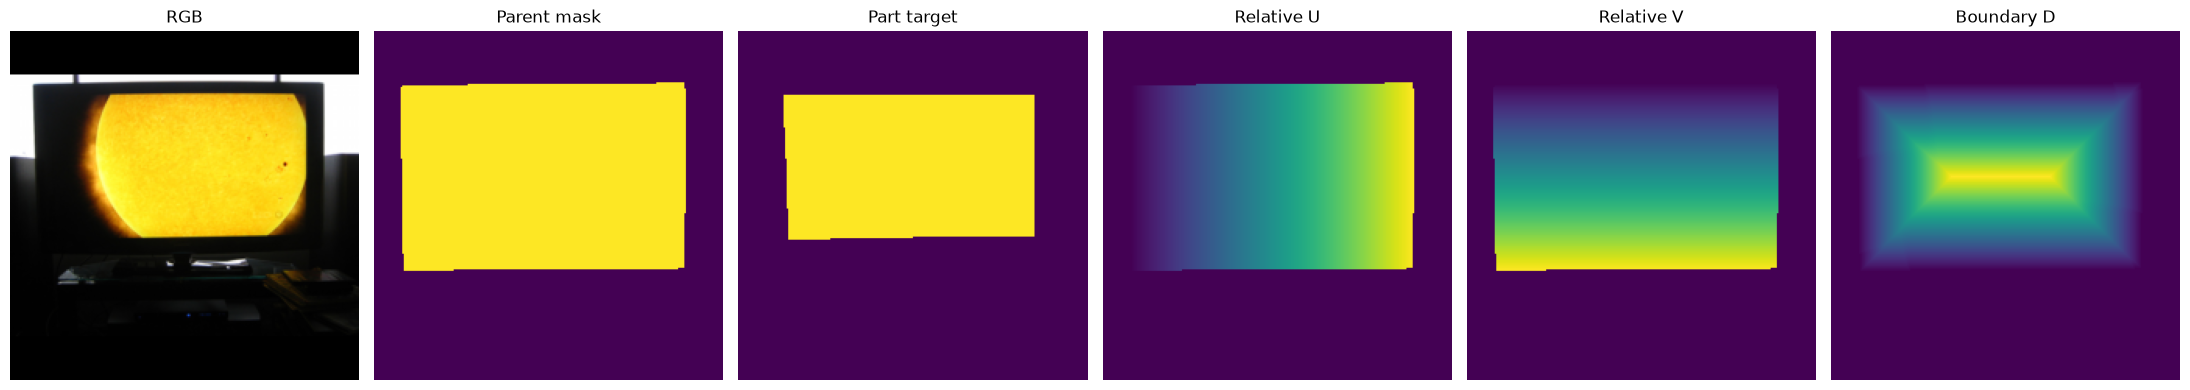

In [34]:
fig, axes = plt.subplots(
    1,
    6,
    figsize=(22, 4),
)

axes[0].imshow(
    display_image
    .permute(
        1,
        2,
        0,
    )
)

axes[0].set_title(
    "RGB"
)

axes[1].imshow(
    object_mask.squeeze()
)

axes[1].set_title(
    "Parent mask"
)

axes[2].imshow(
    part_mask.squeeze()
)

axes[2].set_title(
    "Part target"
)

axes[3].imshow(
    relative_u.squeeze(),
    vmin=0,
    vmax=1,
)

axes[3].set_title(
    "Relative U"
)

axes[4].imshow(
    relative_v.squeeze(),
    vmin=0,
    vmax=1,
)

axes[4].set_title(
    "Relative V"
)

axes[5].imshow(
    boundary_d.squeeze(),
    vmin=0,
    vmax=1,
)

axes[5].set_title(
    "Boundary D"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## UVD dataset wrapper

The wrapper applies identical preprocessing across splits, computes U/V/D from the resized parent mask, and returns all tensors required by the segmentation model.


In [35]:
class UVDDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = (
            image_size
        )

    def __len__(
        self,
    ):

        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index,
    ):

        sample = (
            self.base_dataset[
                index
            ]
        )

        (
            display_image,
            image,
            resize_info,
        ) = preprocess_image(
            sample["image"],
            self.image_size,
        )

        object_mask = (
            preprocess_mask(
                sample[
                    "object_mask"
                ],
                resize_info,
                preserve_positive=True,
            )
        )

        part_mask = (
            preprocess_mask(
                sample[
                    "part_mask"
                ],
                resize_info,
                preserve_positive=True,
            )
        )

        overlap = (
            object_mask
            & part_mask
        )

        if (
            part_mask.any()
            and not overlap.any()
        ):

            object_mask = (
                object_mask
                | part_mask
            )

        part_mask = (
            part_mask
            & object_mask
        )

        (
            relative_u,
            relative_v,
        ) = create_relative_uv(
            object_mask
        )

        boundary_d = (
            create_boundary_distance(
                object_mask
            )
        )

        return {

            "sample_id":
                sample[
                    "sample_id"
                ],

            "image_id":
                sample[
                    "image_id"
                ],

            "image":
                image,

            "display_image":
                display_image,

            "object_mask":
                object_mask.float(),

            "part_mask":
                part_mask.float(),

            "relative_u":
                relative_u,

            "relative_v":
                relative_v,

            "boundary_d":
                boundary_d,

            "query":
                sample[
                    "query"
                ],

            "object_name":
                sample[
                    "object_name"
                ],

            "part_name":
                sample[
                    "part_name"
                ],

            "evaluation_split":
                sample[
                    "evaluation_split"
                ],
        }


## Create train/validation/test datasets


In [36]:
train_dataset = UVDDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
)

val_dataset = UVDDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
)

test_seen_dataset = UVDDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
)

test_unseen_dataset = UVDDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
)

print(
    "Train:",
    len(train_dataset),
)

print(
    "Validation:",
    len(val_dataset),
)

print(
    "Seen:",
    len(test_seen_dataset),
)

print(
    "Unseen:",
    len(test_unseen_dataset),
)


Train: 32698
Validation: 3708
Seen: 3371
Unseen: 1586


## Inspect one processed sample


In [37]:
sample = (
    train_dataset[0]
)

for key, value in (
    sample.items()
):

    if torch.is_tensor(
        value
    ):

        print(
            f"{key:20s}",
            tuple(
                value.shape
            ),
            value.dtype,
        )

    else:

        print(
            f"{key:20s}",
            value,
        )


sample_id            train:2008_000002:part_115
image_id             2008_000002
image                (3, 224, 224) torch.float32
display_image        (3, 224, 224) torch.float32
object_mask          (1, 224, 224) torch.float32
part_mask            (1, 224, 224) torch.float32
relative_u           (1, 224, 224) torch.float32
relative_v           (1, 224, 224) torch.float32
boundary_d           (1, 224, 224) torch.float32
query                screen
object_name          tvmonitor
part_name            screen
evaluation_split     seen


## Validate sample invariants


In [38]:
def validate_uvd_sample(
    sample,
):

    expected_image_shape = (
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    expected_map_shape = (
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    assert (
        sample["image"].shape
        == expected_image_shape
    )

    for key in [
        "object_mask",
        "part_mask",
        "relative_u",
        "relative_v",
        "boundary_d",
    ]:

        assert (
            sample[key].shape
            == expected_map_shape
        ), key

    obj = (
        sample[
            "object_mask"
        ] > 0.5
    )

    part = (
        sample[
            "part_mask"
        ] > 0.5
    )

    assert torch.all(
        ~part | obj
    )

    for key in [
        "relative_u",
        "relative_v",
        "boundary_d",
    ]:

        assert (
            sample[key].min()
            >= 0
        )

        assert (
            sample[key].max()
            <= 1
        )

        assert torch.all(
            sample[key][
                ~obj
            ] == 0
        )

    return True


validate_uvd_sample(
    train_dataset[0]
)

print(
    "Sample validation passed."
)


Sample validation passed.


## Validate random training samples


In [39]:
rng = random.Random(
    SEED
)

indices = rng.sample(
    range(
        len(train_dataset)
    ),
    min(
        200,
        len(train_dataset),
    ),
)

for idx in indices:

    validate_uvd_sample(
        train_dataset[idx]
    )

print(
    f"Validated {len(indices)} "
    "UVD samples successfully."
)


Validated 200 UVD samples successfully.


## DataLoaders

On the cluster, multiple workers keep the GPU fed while SciPy computes distance transforms. If multiprocessing is unavailable in another notebook environment, reduce `NUM_WORKERS` to 0.


In [40]:
NUM_WORKERS = 8  # Cluster setting; use 0 if notebook multiprocessing is unsupported.
PIN_MEMORY = DEVICE.type == "cuda"  # Helps host-to-GPU transfer on CUDA.

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("DataLoaders recreated")
print("NUM_WORKERS:", NUM_WORKERS)
print("PIN_MEMORY:", PIN_MEMORY)


DataLoaders recreated
NUM_WORKERS: 8
PIN_MEMORY: True


## Check one batch


In [41]:
batch = next(iter(train_loader))

for key in [
    "image",
    "object_mask",
    "part_mask",
    "relative_u",
    "relative_v",
    "boundary_d",
]:
    print(f"{key:15s}", batch[key].shape)


image           torch.Size([16, 3, 224, 224])
object_mask     torch.Size([16, 1, 224, 224])
part_mask       torch.Size([16, 1, 224, 224])
relative_u      torch.Size([16, 1, 224, 224])
relative_v      torch.Size([16, 1, 224, 224])
boundary_d      torch.Size([16, 1, 224, 224])


## Frozen DINOv2 visual encoder

DINOv2 ViT-S/14 provides dense patch features. Its parameters remain frozen throughout the experiment.


In [42]:
# Load pretrained DINOv2 ViT-S/14 and freeze all backbone parameters.
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)
dino.eval()

for parameter in dino.parameters():
    parameter.requires_grad = False

print("DINOv2 loaded successfully")
print("Device:", DEVICE)
print(
    "Trainable DINO parameters:",
    sum(
        p.numel()
        for p in dino.parameters()
        if p.requires_grad
    ),
)


Using cache found in /home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/hpc/v123be/v123be51/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded successfully
Device: cuda
Trainable DINO parameters: 0


In [43]:
# Load pretrained CLIP text encoder and freeze it.
clip_model, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai",
)

clip_tokenizer = open_clip.get_tokenizer(
    "ViT-B-32"
)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

for parameter in clip_model.parameters():
    parameter.requires_grad = False

print("CLIP loaded successfully")
print("Device:", DEVICE)
print(
    "Trainable CLIP parameters:",
    sum(
        p.numel()
        for p in clip_model.parameters()
        if p.requires_grad
    ),
)


/home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded successfully
Device: cuda
Trainable CLIP parameters: 0


## Frozen CLIP text encoder with caching

Part queries repeat frequently, so normalized CLIP text embeddings are cached after first use.


In [44]:
class TextEmbeddingCache:

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.cache = {}

    @torch.no_grad()
    def _encode_missing(self, queries):

        missing = sorted({
            q for q in queries
            if q not in self.cache
        })

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = self.tokenizer(prompts).to(
            self.device
        )

        embeddings = self.model.encode_text(
            tokens
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for query, embedding in zip(
            missing,
            embeddings,
        ):
            self.cache[query] = (
                embedding.detach().cpu()
            )

    def __call__(self, queries):

        self._encode_missing(queries)

        embeddings = torch.stack([
            self.cache[q]
            for q in queries
        ])

        return embeddings.to(
            self.device
        )


text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

print("Text embedding cache created.")


Text embedding cache created.


## Query geometry gate

The gate maps each 512-D CLIP embedding to three logits and applies softmax to obtain $[\alpha_U, \alpha_V, \alpha_D]$.


In [45]:
class QueryGeometryGate(nn.Module):

    def __init__(
        self,
        input_dim=512,
        hidden_dim=64,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Linear(
                hidden_dim,
                3,
            ),
        )

    def forward(
        self,
        text_embeddings,
    ):
        gate_logits = self.network(
            text_embeddings
        )

        # Softmax makes the three geometry weights non-negative and sum to one.
        weights = F.softmax(
            gate_logits,
            dim=-1,
        )

        return weights


print("QueryGeometryGate defined successfully.")


QueryGeometryGate defined successfully.


## Sanity check for the untrained gate

At this point the gate is randomly initialized; only verify that it returns three non-negative weights that sum to one.


In [46]:
example_queries = [
    "head",
    "wheel",
    "screen",
    "wing",
]

example_embeddings = text_encoder(
    example_queries
)

test_gate = QueryGeometryGate(
    input_dim=512,
    hidden_dim=64,
).to(DEVICE)

with torch.no_grad():
    example_weights = test_gate(
        example_embeddings
    )

for query, weights in zip(
    example_queries,
    example_weights,
):
    print(
        query,
        weights.cpu().numpy().round(4),
        "sum =",
        round(
            weights.sum().item(),
            4,
        ),
    )


head [0.3171 0.3643 0.3186] sum = 1.0
wheel [0.3176 0.3638 0.3186] sum = 1.0
screen [0.317  0.3645 0.3185] sum = 1.0
wing [0.3181 0.364  0.3179] sum = 1.0


## Segmentation model

`UVDPartSegmenter` fuses projected DINOv2 features, projected CLIP text, the parent mask, and three geometry channels. `fixed_uvd` uses raw geometry; `query_gated_uvd` modulates each geometry channel with the query-specific gate weight.


In [47]:
class UVDPartSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_dim=32,
        gate_hidden_dim=64,
    ):
        super().__init__()

        assert mode in {
            "fixed_uvd",
            "query_gated_uvd",
        }

        self.mode = mode
        self.dino = dino_encoder

        for parameter in self.dino.parameters():
            parameter.requires_grad = False

        self.visual_projection = nn.Conv2d(
            384,
            visual_dim,
            kernel_size=1,
        )

        self.text_projection = nn.Sequential(
            nn.Linear(
                512,
                64,
            ),
            nn.GELU(),
            nn.Linear(
                64,
                text_dim,
            ),
        )

        if mode == "query_gated_uvd":
            self.geometry_gate = QueryGeometryGate(
                input_dim=512,
                hidden_dim=gate_hidden_dim,
            )
        else:
            self.geometry_gate = None

        fusion_dim = (
            visual_dim
            + text_dim
            + 1   # parent mask
            + 3   # U, V, D
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                128,
            ),
            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                64,
            ),
            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        # Keep frozen DINO in eval mode
        self.dino.eval()

        return self

    def extract_dino_features(
        self,
        images,
    ):
        with torch.no_grad():
            output = self.dino.forward_features(
                images
            )

            tokens = output[
                "x_norm_patchtokens"
            ]

        batch_size, num_tokens, channels = (
            tokens.shape
        )

        grid_size = int(
            num_tokens ** 0.5
        )

        features = (
            tokens
            .transpose(
                1,
                2,
            )
            .reshape(
                batch_size,
                channels,
                grid_size,
                grid_size,
            )
        )

        return features

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        relative_u,
        relative_v,
        boundary_d,
        return_gate_weights=False,
    ):

        dino_features = (
            self.extract_dino_features(
                images
            )
        )

        visual = self.visual_projection(
            dino_features
        )

        text = self.text_projection(
            text_embeddings
        )

        text_map = (
            text[
                :,
                :,
                None,
                None,
            ]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        spatial_size = (
            visual.shape[-2:]
        )

        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )

        u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        d_low = F.interpolate(
            boundary_d,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        u_low = u_low * mask_low
        v_low = v_low * mask_low
        d_low = d_low * mask_low

        # Fixed mode keeps raw geometry; gated mode applies query-specific weights.
        if self.mode == "fixed_uvd":
            gate_weights = torch.ones(
                (
                    images.shape[0],
                    3,
                ),
                device=images.device,
                dtype=visual.dtype,
            )

            weighted_u = u_low
            weighted_v = v_low
            weighted_d = d_low

        else:
            gate_weights = self.geometry_gate(
                text_embeddings.float()
            )

            alpha_u = gate_weights[:, 0].view(
                -1,
                1,
                1,
                1,
            )

            alpha_v = gate_weights[:, 1].view(
                -1,
                1,
                1,
                1,
            )

            alpha_d = gate_weights[:, 2].view(
                -1,
                1,
                1,
                1,
            )

            weighted_u = alpha_u * u_low
            weighted_v = alpha_v * v_low
            weighted_d = alpha_d * d_low

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                weighted_u,
                weighted_v,
                weighted_d,
            ],
            dim=1,
        )

        logits_low = self.decoder(
            fused
        )

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        if return_gate_weights:
            return (
                logits,
                gate_weights,
            )

        return logits


print("UVDPartSegmenter defined successfully.")


UVDPartSegmenter defined successfully.


## Compare trainable parameter counts


In [48]:
modes = [
    "fixed_uvd",
    "query_gated_uvd",
]

parameter_counts = {}

for mode in modes:

    model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    parameter_counts[mode] = trainable

for mode, count in parameter_counts.items():
    print(
        f"{mode:20s}",
        f"{count:,} trainable parameters",
    )

print(
    "\nExtra parameters from query gate:",
    f"{parameter_counts['query_gated_uvd'] - parameter_counts['fixed_uvd']:,}",
)


fixed_uvd            365,921 trainable parameters
query_gated_uvd      398,948 trainable parameters

Extra parameters from query gate: 33,027


## Forward-pass sanity check


In [49]:
batch = next(iter(train_loader))

images = batch["image"].to(DEVICE)
object_masks = batch["object_mask"].to(DEVICE)
relative_u = batch["relative_u"].to(DEVICE)
relative_v = batch["relative_v"].to(DEVICE)
boundary_d = batch["boundary_d"].to(DEVICE)

text_embeddings = text_encoder(
    batch["query"]
)

for mode in [
    "fixed_uvd",
    "query_gated_uvd",
]:
    test_model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)

    with torch.no_grad():
        output = test_model(
            images,
            text_embeddings,
            object_masks,
            relative_u,
            relative_v,
            boundary_d,
        )

    print(
        mode,
        output.shape,
        "finite:",
        torch.isfinite(output).all().item(),
    )


fixed_uvd torch.Size([16, 1, 224, 224]) finite: True
query_gated_uvd torch.Size([16, 1, 224, 224]) finite: True


## Dice loss


In [50]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):
    probabilities = torch.sigmoid(
        logits
    ).flatten(1)

    targets = targets.flatten(1)

    intersection = (
        probabilities
        * targets
    ).sum(dim=1)

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection
        + eps
    ) / (
        denominator
        + eps
    )

    return (
        1 - dice
    ).mean()


print("Dice loss defined successfully.")


Dice loss defined successfully.


## BCE + Dice segmentation loss


In [51]:
def segmentation_loss(
    logits,
    targets,
):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
    )

    dice = dice_loss(
        logits,
        targets,
    )

    total = bce + dice

    return {
        "total": total,
        "bce": bce,
        "dice": dice,
    }


print("Segmentation loss defined successfully.")


Segmentation loss defined successfully.


## IoU metric


In [81]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions & targets
    ).sum(dim=1).float()

    union = (
        predictions | targets
    ).sum(dim=1).float()

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    return iou


print("IoU metric defined successfully.")


IoU metric defined successfully.


## Dice metric


In [89]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions & targets
    ).sum(dim=1).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return dice


print("Dice metric defined successfully.")


Dice metric defined successfully.


## Training and evaluation loop

The same loop is used for training and evaluation. CUDA runs use AMP and non-blocking transfers; gradients are clipped for stability.


In [90]:
def run_epoch(
    model,
    loader,
    text_encoder,
    optimizer=None,
    scaler=None,
    threshold=0.5,
    max_batches=None,
):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    for batch_index, batch in enumerate(loader):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        object_mask = batch["object_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["part_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_u = batch["relative_u"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_v = batch["relative_v"].to(
            DEVICE,
            non_blocking=True,
        )

        boundary_d = batch["boundary_d"].to(
            DEVICE,
            non_blocking=True,
        )

        text_embeddings = text_encoder(
            batch["query"]
        )

        batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(training):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(
                    images,
                    text_embeddings,
                    object_mask,
                    relative_u,
                    relative_v,
                    boundary_d,
                )

                losses = segmentation_loss(
                    logits,
                    targets,
                )

            if training:

                if scaler is not None and USE_AMP:

                    scaler.scale(
                        losses["total"]
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    losses["total"].backward()

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    optimizer.step()

        with torch.no_grad():

            ious = batch_iou(
                logits,
                targets,
                threshold,
            )

            dices = batch_dice(
                logits,
                targets,
                threshold,
            )

        total_loss += (
            losses["total"].item()
            * batch_size
        )

        total_iou += ious.sum().item()
        total_dice += dices.sum().item()

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "iou": total_iou / total_samples,
        "dice": total_dice / total_samples,
    }


print("GPU-ready run_epoch defined successfully.")
print("Current device:", DEVICE)
print("AMP enabled:", USE_AMP)


GPU-ready run_epoch defined successfully.
Current device: cuda
AMP enabled: True


## Checkpoint save helper

Only trainable submodules are saved so the frozen DINOv2 backbone is not duplicated in every checkpoint.


In [41]:
# Store only trainable submodules; DINOv2 is frozen and reconstructed separately.
def get_trainable_state(
    model,
):
    state = {
        "visual_projection":
            model.visual_projection.state_dict(),

        "text_projection":
            model.text_projection.state_dict(),

        "decoder":
            model.decoder.state_dict(),
    }

    if model.geometry_gate is not None:
        state["geometry_gate"] = (
            model.geometry_gate.state_dict()
        )

    return state


print("Checkpoint save helper defined successfully.")


Checkpoint save helper defined successfully.


## Checkpoint restore helper


In [42]:
def load_trainable_state(
    model,
    checkpoint,
):
    state = checkpoint["model_state"]

    model.visual_projection.load_state_dict(
        state["visual_projection"]
    )

    model.text_projection.load_state_dict(
        state["text_projection"]
    )

    model.decoder.load_state_dict(
        state["decoder"]
    )

    if model.geometry_gate is not None:
        model.geometry_gate.load_state_dict(
            state["geometry_gate"]
        )

    return model


print("Checkpoint load helper defined successfully.")


Checkpoint load helper defined successfully.


## GPU smoke test

Train for only a few batches before the full run to catch shape, loss, or optimizer errors early.


In [43]:
smoke_model = UVDPartSegmenter(
    dino_encoder=dino,
    mode="query_gated_uvd",
    visual_dim=VISUAL_DIM,
    text_dim=TEXT_DIM,
    gate_hidden_dim=GATE_HIDDEN_DIM,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    (
        p
        for p in smoke_model.parameters()
        if p.requires_grad
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

smoke_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

smoke_metrics = run_epoch(
    smoke_model,
    train_loader,
    text_encoder,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    threshold=MASK_THRESHOLD,
    max_batches=2,
)

print("Smoke test metrics:")
print(smoke_metrics)

del smoke_model
del smoke_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Smoke test metrics:
{'loss': 1.5154582858085632, 'iou': 0.008778873943914078, 'dice': 0.016705285870660447}


## Full experiment training function

Each run stores its configuration, training history, `last.pt`, and the best checkpoint selected by validation IoU. A plateau scheduler reduces the learning rate when validation IoU stalls.


In [98]:
def train_uvd_experiment(
    mode,
    epochs=EPOCHS,
):
    seed_everything(SEED)

    experiment_dir = OUTPUT_ROOT / mode
    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "epochs": epochs,
        "batch_size": TRAIN_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "visual_dim": VISUAL_DIM,
        "text_dim": TEXT_DIM,
        "gate_hidden_dim": GATE_HIDDEN_DIM,
        "threshold": MASK_THRESHOLD,
        "dino": "dinov2_vits14",
        "clip": "ViT-B-32/openai",
    }

    with open(
        experiment_dir / "config.json",
        "w",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
        )

    history = []
    # Select checkpoints by validation IoU.
    best_val_iou = -1.0

    for epoch in range(
        1,
        epochs + 1,
    ):
        start_time = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            text_encoder,
            optimizer=optimizer,
            scaler=scaler,
            threshold=MASK_THRESHOLD,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            text_encoder,
            optimizer=None,
            scaler=None,
            threshold=MASK_THRESHOLD,
        )

        scheduler.step(
            val_metrics["iou"]
        )

        elapsed = (
            time.time()
            - start_time
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_iou": val_metrics["iou"],
            "val_dice": val_metrics["dice"],
            "learning_rate": current_lr,
            "seconds": elapsed,
        }

        history.append(row)

        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train IoU {train_metrics['iou']:.4f} | "
            f"val IoU {val_metrics['iou']:.4f} | "
            f"val Dice {val_metrics['dice']:.4f} | "
            f"lr {current_lr:.2e} | "
            f"{elapsed:.1f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "mode": mode,
            "model_state": get_trainable_state(
                model
            ),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_metrics": val_metrics,
            "config": config,
        }

        torch.save(
            checkpoint,
            experiment_dir / "last.pt",
        )

        if (
            val_metrics["iou"]
            > best_val_iou
        ):
            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir / "best.pt",
            )

            print(
                f"  -> New best model saved "
                f"(val IoU={best_val_iou:.4f})"
            )

        with open(
            experiment_dir / "history.json",
            "w",
        ) as f:
            json.dump(
                history,
                f,
                indent=2,
            )

    print()
    print(
        f"Training complete: {mode}"
    )
    print(
        f"Best validation IoU: "
        f"{best_val_iou:.4f}"
    )
    print(
        f"Saved to: {experiment_dir}"
    )

    return model, history


print("Full experiment training function defined.")


Full experiment training function defined.


## Throughput check and full training

Time a small number of batches first to verify the DataLoader is not starving the GPU, then train the fixed-UVD baseline and the query-gated model.


In [53]:
import time

start = time.time()

for i, batch in enumerate(train_loader):
    if i >= 20:
        break

elapsed = time.time() - start

print(f"20 batches took: {elapsed:.2f} seconds")
print(f"Average per batch: {elapsed / 20:.3f} seconds")


20 batches took: 1.26 seconds
Average per batch: 0.063 seconds


In [54]:
fixed_uvd_model, fixed_uvd_history = train_uvd_experiment(
    mode="fixed_uvd",
    epochs=EPOCHS,
)


[fixed_uvd] Epoch 01/20 | train loss 0.8520 | train IoU 0.1586 | val IoU 0.2073 | val Dice 0.2835 | lr 1.00e-03 | 72.0s
  -> New best model saved (val IoU=0.2073)
[fixed_uvd] Epoch 02/20 | train loss 0.7617 | train IoU 0.2249 | val IoU 0.2352 | val Dice 0.3205 | lr 1.00e-03 | 76.4s
  -> New best model saved (val IoU=0.2352)
[fixed_uvd] Epoch 03/20 | train loss 0.7240 | train IoU 0.2518 | val IoU 0.2463 | val Dice 0.3325 | lr 1.00e-03 | 71.7s
  -> New best model saved (val IoU=0.2463)
[fixed_uvd] Epoch 04/20 | train loss 0.6967 | train IoU 0.2721 | val IoU 0.2627 | val Dice 0.3527 | lr 1.00e-03 | 72.0s
  -> New best model saved (val IoU=0.2627)
[fixed_uvd] Epoch 05/20 | train loss 0.6729 | train IoU 0.2898 | val IoU 0.2796 | val Dice 0.3738 | lr 1.00e-03 | 77.0s
  -> New best model saved (val IoU=0.2796)
[fixed_uvd] Epoch 06/20 | train loss 0.6551 | train IoU 0.3031 | val IoU 0.2746 | val Dice 0.3678 | lr 1.00e-03 | 78.0s
[fixed_uvd] Epoch 07/20 | train loss 0.6420 | train IoU 0.3138 | 

In [55]:
gated_uvd_model, gated_uvd_history = train_uvd_experiment(
    mode="query_gated_uvd",
    epochs=EPOCHS,
)


[query_gated_uvd] Epoch 01/20 | train loss 0.8724 | train IoU 0.1466 | val IoU 0.1876 | val Dice 0.2652 | lr 1.00e-03 | 85.6s
  -> New best model saved (val IoU=0.1876)
[query_gated_uvd] Epoch 02/20 | train loss 0.7767 | train IoU 0.2153 | val IoU 0.2315 | val Dice 0.3196 | lr 1.00e-03 | 77.1s
  -> New best model saved (val IoU=0.2315)
[query_gated_uvd] Epoch 03/20 | train loss 0.7317 | train IoU 0.2472 | val IoU 0.2490 | val Dice 0.3385 | lr 1.00e-03 | 71.7s
  -> New best model saved (val IoU=0.2490)
[query_gated_uvd] Epoch 04/20 | train loss 0.6991 | train IoU 0.2710 | val IoU 0.2577 | val Dice 0.3487 | lr 1.00e-03 | 76.6s
  -> New best model saved (val IoU=0.2577)
[query_gated_uvd] Epoch 05/20 | train loss 0.6749 | train IoU 0.2884 | val IoU 0.2749 | val Dice 0.3667 | lr 1.00e-03 | 71.5s
  -> New best model saved (val IoU=0.2749)
[query_gated_uvd] Epoch 06/20 | train loss 0.6568 | train IoU 0.3026 | val IoU 0.2858 | val Dice 0.3813 | lr 1.00e-03 | 71.5s
  -> New best model saved (va

In [91]:
@torch.no_grad()
def evaluate_model(
    model,
    loader,
):
    return run_epoch(
        model,
        loader,
        text_encoder,
        optimizer=None,
        scaler=None,
        threshold=MASK_THRESHOLD,
    )


fixed_seen = evaluate_model(
    best_fixed_model,
    test_seen_loader,
)

fixed_unseen = evaluate_model(
    best_fixed_model,
    test_unseen_loader,
)

gated_seen = evaluate_model(
    best_gated_model,
    test_seen_loader,
)

gated_unseen = evaluate_model(
    best_gated_model,
    test_unseen_loader,
)

print("Fixed UVD")
print("Seen:", fixed_seen)
print("Unseen:", fixed_unseen)

print()

print("Query-Gated UVD")
print("Seen:", gated_seen)
print("Unseen:", gated_unseen)


Fixed UVD
Seen: {'loss': 1.6936736375632748, 'iou': 0.02017976254008178, 'dice': 0.03693746032761877}
Unseen: {'loss': 1.6900479333548046, 'iou': 0.01816027487121983, 'dice': 0.03363652430324431}

Query-Gated UVD
Seen: {'loss': 1.7024439787942485, 'iou': 0.019656601410278474, 'dice': 0.03602746237998757}
Unseen: {'loss': 1.7046206182369217, 'iou': 0.018551060910809967, 'dice': 0.03435329292180935}


## Load the best checkpoints correctly

The checkpoint contains separate state dictionaries for each trainable submodule. Load them explicitly. Using `model.load_state_dict(checkpoint["model_state"], strict=False)` would silently leave these trained weights unloaded because the nested keys do not match the full model keys.


In [101]:
def load_best_uvd_model(mode):
    checkpoint_path = OUTPUT_ROOT / mode / "best.pt"

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)

    state = checkpoint["model_state"]

    model.visual_projection.load_state_dict(
        state["visual_projection"]
    )

    model.text_projection.load_state_dict(
        state["text_projection"]
    )

    model.decoder.load_state_dict(
        state["decoder"]
    )

    if mode == "query_gated_uvd":
        model.geometry_gate.load_state_dict(
            state["geometry_gate"]
        )

    model.eval()

    return model, checkpoint


best_fixed_model, fixed_checkpoint = load_best_uvd_model("fixed_uvd")
best_gated_model, gated_checkpoint = load_best_uvd_model("query_gated_uvd")

print("Best checkpoints loaded correctly.")


Best checkpoints loaded correctly.


## Verify checkpoint restoration

Re-evaluate the best checkpoints on the validation split. The reproduced IoU should match the value saved during training; this is a guard against checkpoint-loading mistakes.


In [ ]:
@torch.no_grad()
def evaluate_model(model, loader):
    """Evaluate with the same loss, threshold, IoU, and Dice used during validation."""
    return run_epoch(
        model,
        loader,
        text_encoder,
        optimizer=None,
        scaler=None,
        threshold=MASK_THRESHOLD,
    )


In [102]:
fixed_val_check = evaluate_model(
    best_fixed_model,
    val_loader,
)

gated_val_check = evaluate_model(
    best_gated_model,
    val_loader,
)

print("Fixed checkpoint validation:", fixed_val_check)
print("Gated checkpoint validation:", gated_val_check)


Fixed checkpoint validation: {'loss': 0.6595122241922439, 'iou': 0.3010619076967497, 'dice': 0.39612072386337843}
Gated checkpoint validation: {'loss': 0.659104630785081, 'iou': 0.3018886302522471, 'dice': 0.39790494891110617}


## Seen and unseen test performance

These are the primary aggregate results. The unseen split is especially important because the research question focuses on transfer to unseen parent-object categories.


In [103]:
fixed_seen = evaluate_model(
    best_fixed_model,
    test_seen_loader,
)

fixed_unseen = evaluate_model(
    best_fixed_model,
    test_unseen_loader,
)

gated_seen = evaluate_model(
    best_gated_model,
    test_seen_loader,
)

gated_unseen = evaluate_model(
    best_gated_model,
    test_unseen_loader,
)

print("Fixed UVD")
print("Seen:", fixed_seen)
print("Unseen:", fixed_unseen)

print()

print("Query-Gated UVD")
print("Seen:", gated_seen)
print("Unseen:", gated_unseen)


Fixed UVD
Seen: {'loss': 0.6502324460310245, 'iou': 0.31219044526653805, 'dice': 0.41005145658268416}
Unseen: {'loss': 0.7433445951977714, 'iou': 0.24653481971120172, 'dice': 0.3391178337126632}

Query-Gated UVD
Seen: {'loss': 0.650869518863239, 'iou': 0.3116910393957355, 'dice': 0.4098231691311248}
Unseen: {'loss': 0.7416709754686488, 'iou': 0.24736508108853994, 'dice': 0.3414595159801829}


## Learned gate analysis

Inspect the learned weights after training. They indicate whether each part query emphasizes horizontal position (U), vertical position (V), or boundary distance (D).


In [104]:
@torch.no_grad()
def get_query_weights(
    model,
    queries,
):
    embeddings = text_encoder(
        queries
    )

    weights = model.geometry_gate(
        embeddings.float()
    )

    rows = []

    for query, weight in zip(
        queries,
        weights,
    ):
        rows.append(
            {
                "query": query,
                "alpha_u": weight[0].item(),
                "alpha_v": weight[1].item(),
                "alpha_d": weight[2].item(),
            }
        )

    return pd.DataFrame(rows)


example_queries = [
    "head",
    "wheel",
    "leg",
    "wing",
    "screen",
    "window",
    "door",
    "tail",
]

query_weights = get_query_weights(
    best_gated_model,
    example_queries,
)

query_weights


,query,alpha_u,alpha_v,alpha_d
0,head,7.038302e-07,0.999999,1.212851e-11
1,wheel,2.915824e-07,1.000000,1.901057e-11
2,leg,1.183029e-06,0.999999,8.796676e-12
3,wing,9.999967e-01,0.000003,6.621652e-08
4,screen,9.922926e-06,0.999990,1.148122e-09
5,window,1.287655e-04,0.999871,4.236339e-08
6,door,9.999903e-01,0.000009,3.639164e-07
7,tail,4.489269e-04,0.999551,1.699391e-09


In [105]:
all_queries = set()

for batch in val_loader:
    all_queries.update(batch["query"])

all_queries = sorted(all_queries)

print("Number of unique validation queries:", len(all_queries))
print(all_queries[:20])


Number of unique validation queries: 41
['back', 'body', 'cap', 'chainwheel', 'coach', 'door', 'ear', 'engine', 'eye', 'eyebrow', 'foot', 'front', 'hair', 'hand', 'handlebar', 'head', 'headlight', 'hoof', 'horn', 'leg']


In [106]:
all_query_weights = get_query_weights(
    best_gated_model,
    all_queries,
)

print("Mean gate weights:")
print(
    all_query_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ].mean()
)

print("\nDominant geometry counts:")
print(
    all_query_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ]
    .idxmax(axis=1)
    .value_counts()
)


Mean gate weights:
alpha_u    3.902555e-01
alpha_v    6.097444e-01
alpha_d    4.605441e-08
dtype: float64

Dominant geometry counts:
alpha_v    25
alpha_u    16
Name: count, dtype: int64


In [107]:
all_query_weights["dominant"] = (
    all_query_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ]
    .idxmax(axis=1)
)

print("Queries dominated by U:")
print(
    all_query_weights[
        all_query_weights["dominant"] == "alpha_u"
    ][
        ["query", "alpha_u", "alpha_v", "alpha_d"]
    ]
    .sort_values("alpha_u", ascending=False)
    .to_string(index=False)
)

print("\nQueries dominated by V:")
print(
    all_query_weights[
        all_query_weights["dominant"] == "alpha_v"
    ][
        ["query", "alpha_u", "alpha_v", "alpha_d"]
    ]
    .sort_values("alpha_v", ascending=False)
    .to_string(index=False)
)


Queries dominated by U:
    query  alpha_u      alpha_v      alpha_d
      ear 1.000000 5.648867e-11 1.038300e-10
  eyebrow 1.000000 2.333038e-08 4.561136e-09
     hair 1.000000 6.182765e-08 3.216200e-09
upper arm 1.000000 3.436964e-07 1.100904e-08
handlebar 1.000000 4.888079e-07 2.842263e-08
      eye 1.000000 4.267917e-07 2.069446e-08
     wing 0.999997 3.223897e-06 6.621639e-08
     hand 0.999993 6.832832e-06 3.094333e-08
     door 0.999990 9.338119e-06 3.639164e-07
     horn 0.999987 1.349455e-05 1.632545e-08
lower arm 0.999987 1.352912e-05 2.867547e-08
     roof 0.999975 2.453030e-05 3.155509e-07
   mirror 0.999947 5.245119e-05 5.914310e-07
     hoof 0.999945 5.484067e-05 3.097663e-08
   saddle 0.999912 8.746469e-05 9.097365e-08
      paw 0.999765 2.349813e-04 2.281518e-07

Queries dominated by V:
        query      alpha_u  alpha_v      alpha_d
          pot 1.132046e-08 1.000000 8.745040e-13
        plant 1.746766e-07 1.000000 2.498335e-11
        wheel 2.915829e-07 1.000000 1.9

In [108]:
all_query_weights["gate_confidence"] = (
    all_query_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ].max(axis=1)
)

print(
    all_query_weights[
        [
            "query",
            "dominant",
            "gate_confidence",
        ]
    ]
    .sort_values(
        "gate_confidence",
        ascending=False,
    )
    .to_string(index=False)
)

print(
    "\nMean gate confidence:",
    all_query_weights["gate_confidence"].mean(),
)


        query dominant  gate_confidence
          ear  alpha_u         1.000000
          pot  alpha_v         1.000000
      eyebrow  alpha_u         1.000000
         hair  alpha_u         1.000000
        plant  alpha_v         1.000000
        wheel  alpha_v         1.000000
license plate  alpha_v         1.000000
    upper arm  alpha_u         1.000000
          eye  alpha_u         1.000000
    handlebar  alpha_u         1.000000
        front  alpha_v         0.999999
        torso  alpha_v         0.999999
         head  alpha_v         0.999999
         body  alpha_v         0.999999
          leg  alpha_v         0.999999
         wing  alpha_u         0.999997
       muzzle  alpha_v         0.999996
         side  alpha_v         0.999995
         hand  alpha_u         0.999993
        coach  alpha_v         0.999993
         door  alpha_u         0.999990
       screen  alpha_v         0.999990
         horn  alpha_u         0.999987
    lower arm  alpha_u         0.999987


## Per-query unseen-category analysis

Aggregate IoU by part query on the unseen-object split. This reveals whether a small aggregate difference hides query-specific gains or regressions.


In [109]:
from collections import defaultdict

@torch.no_grad()
def per_query_iou_comparison(
    fixed_model,
    gated_model,
    loader,
):
    results = defaultdict(
        lambda: {
            "fixed": [],
            "gated": [],
        }
    )

    fixed_model.eval()
    gated_model.eval()

    for batch in loader:

        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        object_mask = batch["object_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["part_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_u = batch["relative_u"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_v = batch["relative_v"].to(
            DEVICE,
            non_blocking=True,
        )

        boundary_d = batch["boundary_d"].to(
            DEVICE,
            non_blocking=True,
        )

        text_embeddings = text_encoder(
            batch["query"]
        )

        fixed_logits = fixed_model(
            images,
            text_embeddings,
            object_mask,
            relative_u,
            relative_v,
            boundary_d,
        )

        gated_logits = gated_model(
            images,
            text_embeddings,
            object_mask,
            relative_u,
            relative_v,
            boundary_d,
        )

        fixed_ious = batch_iou(
            fixed_logits,
            targets,
            MASK_THRESHOLD,
        ).cpu()

        gated_ious = batch_iou(
            gated_logits,
            targets,
            MASK_THRESHOLD,
        ).cpu()

        for query, fixed_iou, gated_iou in zip(
            batch["query"],
            fixed_ious,
            gated_ious,
        ):
            results[query]["fixed"].append(
                fixed_iou.item()
            )

            results[query]["gated"].append(
                gated_iou.item()
            )

    rows = []

    for query, values in results.items():

        fixed_mean = np.mean(
            values["fixed"]
        )

        gated_mean = np.mean(
            values["gated"]
        )

        rows.append(
            {
                "query": query,
                "count": len(
                    values["fixed"]
                ),
                "fixed_iou": fixed_mean,
                "gated_iou": gated_mean,
                "gain": (
                    gated_mean
                    - fixed_mean
                ),
            }
        )

    return pd.DataFrame(rows)


unseen_query_results = (
    per_query_iou_comparison(
        best_fixed_model,
        best_gated_model,
        test_unseen_loader,
    )
)

print(
    unseen_query_results
    .sort_values(
        "gain",
        ascending=False,
    )
    .to_string(
        index=False
    )
)


        query  count    fixed_iou    gated_iou          gain
         horn      4 1.811594e-02 1.638485e-01  1.457326e-01
         nose     69 1.275407e-01 2.133866e-01  8.584585e-02
         side     42 1.814812e-01 2.539856e-01  7.250433e-02
         tail     95 1.508362e-01 2.031887e-01  5.235246e-02
        wheel     78 3.825311e-01 4.228113e-01  4.028023e-02
         back     21 2.484535e-01 2.701409e-01  2.168744e-02
          paw     52 2.258424e-01 2.448463e-01  1.900386e-02
       muzzle    100 2.771791e-01 2.958966e-01  1.871754e-02
        front     29 2.834086e-01 3.003111e-01  1.690249e-02
         roof     14 5.245261e-02 6.927105e-02  1.681844e-02
       mirror     31 1.672074e-03 1.791022e-02  1.623814e-02
         foot     33 3.279785e-03 1.436525e-02  1.108547e-02
         neck     83 2.727095e-01 2.831730e-01  1.046352e-02
    handlebar      1 1.747573e-01 1.828154e-01  8.058071e-03
          eye    148 8.993540e-02 9.050974e-02  5.743405e-04
license plate      3 3.6

In [110]:
print("Unseen queries:", len(unseen_query_results))

print(
    "Gated better:",
    (unseen_query_results["gain"] > 0).sum()
)

print(
    "Fixed better:",
    (unseen_query_results["gain"] < 0).sum()
)

print(
    "Mean per-query gain:",
    unseen_query_results["gain"].mean()
)

print(
    "Median per-query gain:",
    unseen_query_results["gain"].median()
)


Unseen queries: 25
Gated better: 16
Fixed better: 9
Mean per-query gain: 0.00921133772644311
Median per-query gain: 0.01046351948341967


In [111]:
analysis_df = unseen_query_results.merge(
    all_query_weights[
        [
            "query",
            "dominant",
            "alpha_u",
            "alpha_v",
            "alpha_d",
            "gate_confidence",
        ]
    ],
    on="query",
    how="left",
)

print(
    analysis_df[
        [
            "query",
            "count",
            "fixed_iou",
            "gated_iou",
            "gain",
            "dominant",
            "gate_confidence",
        ]
    ]
    .sort_values(
        "gain",
        ascending=False,
    )
    .to_string(index=False)
)

print("\nMean gain by dominant cue:")
print(
    analysis_df
    .groupby("dominant")["gain"]
    .agg(
        ["count", "mean", "median"]
    )
)


        query  count    fixed_iou    gated_iou          gain dominant  gate_confidence
         horn      4 1.811594e-02 1.638485e-01  1.457326e-01  alpha_u         0.999987
         nose     69 1.275407e-01 2.133866e-01  8.584585e-02  alpha_v         0.999956
         side     42 1.814812e-01 2.539856e-01  7.250433e-02  alpha_v         0.999995
         tail     95 1.508362e-01 2.031887e-01  5.235246e-02  alpha_v         0.999551
        wheel     78 3.825311e-01 4.228113e-01  4.028023e-02  alpha_v         1.000000
         back     21 2.484535e-01 2.701409e-01  2.168744e-02  alpha_v         0.999985
          paw     52 2.258424e-01 2.448463e-01  1.900386e-02  alpha_u         0.999765
       muzzle    100 2.771791e-01 2.958966e-01  1.871754e-02  alpha_v         0.999996
        front     29 2.834086e-01 3.003111e-01  1.690249e-02  alpha_v         0.999999
         roof     14 5.245261e-02 6.927105e-02  1.681844e-02  alpha_u         0.999975
       mirror     31 1.672074e-03 1.791022e

In [112]:
unseen_queries = sorted(
    unseen_query_results["query"].unique()
)

unseen_gate_weights = get_query_weights(
    best_gated_model,
    unseen_queries,
)

unseen_gate_weights["dominant"] = (
    unseen_gate_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ]
    .idxmax(axis=1)
)

print(
    unseen_gate_weights
    .sort_values("query")
    .to_string(index=False)
)


        query      alpha_u      alpha_v      alpha_d dominant
         back 1.527716e-05 9.999847e-01 1.082258e-09  alpha_v
         beak 9.941313e-01 5.868339e-03 3.504637e-07  alpha_u
         door 9.999903e-01 9.338119e-06 3.639164e-07  alpha_u
          ear 1.000000e+00 5.648867e-11 1.038300e-10  alpha_u
          eye 9.999995e-01 4.267917e-07 2.069446e-08  alpha_u
         foot 7.331893e-05 9.999267e-01 3.548602e-10  alpha_v
        front 5.683827e-07 9.999994e-01 3.977187e-11  alpha_v
    handlebar 9.999995e-01 4.888079e-07 2.842263e-08  alpha_u
         head 7.038308e-07 9.999993e-01 1.212848e-11  alpha_v
    headlight 1.901575e-05 9.999809e-01 2.890698e-09  alpha_v
         horn 9.999865e-01 1.349455e-05 1.632545e-08  alpha_u
          leg 1.183028e-06 9.999988e-01 8.796676e-12  alpha_v
license plate 2.121452e-07 9.999998e-01 1.690743e-10  alpha_v
       mirror 9.999470e-01 5.245119e-05 5.914310e-07  alpha_u
       muzzle 4.179683e-06 9.999958e-01 8.751903e-11  alpha_v
        

In [113]:
unseen_analysis = unseen_query_results.merge(
    unseen_gate_weights[
        [
            "query",
            "dominant",
            "alpha_u",
            "alpha_v",
            "alpha_d",
        ]
    ],
    on="query",
    how="left",
)

print("Performance gain by dominant geometry:")
print(
    unseen_analysis
    .groupby("dominant")["gain"]
    .agg(
        count="count",
        mean="mean",
        median="median",
    )
)

print("\nWins / losses by dominant geometry:")
print(
    unseen_analysis
    .assign(
        result=np.where(
            unseen_analysis["gain"] > 0,
            "Gated better",
            "Fixed better",
        )
    )
    .groupby(
        ["dominant", "result"]
    )
    .size()
)


Performance gain by dominant geometry:
          count      mean    median
dominant                           
alpha_u      10  0.000462  0.004316
alpha_v      15  0.015044  0.011085

Wins / losses by dominant geometry:
dominant  result      
alpha_u   Fixed better     4
          Gated better     6
alpha_v   Fixed better     5
          Gated better    10
dtype: int64


## Save core analysis artifacts

Persist aggregate metrics, per-query results, and gate statistics so later notebooks can reuse the results without retraining.


In [114]:
results_summary = {
    "fixed_uvd": {
        "best_epoch": fixed_checkpoint["epoch"],
        "val_iou": fixed_checkpoint["val_metrics"]["iou"],
        "seen_iou": fixed_seen["iou"],
        "seen_dice": fixed_seen["dice"],
        "unseen_iou": fixed_unseen["iou"],
        "unseen_dice": fixed_unseen["dice"],
    },
    "query_gated_uvd": {
        "best_epoch": gated_checkpoint["epoch"],
        "val_iou": gated_checkpoint["val_metrics"]["iou"],
        "seen_iou": gated_seen["iou"],
        "seen_dice": gated_seen["dice"],
        "unseen_iou": gated_unseen["iou"],
        "unseen_dice": gated_unseen["dice"],
    },
    "unseen_gain": {
        "iou": gated_unseen["iou"] - fixed_unseen["iou"],
        "dice": gated_unseen["dice"] - fixed_unseen["dice"],
    },
    "gate_analysis": {
        "mean_alpha_u": float(unseen_gate_weights["alpha_u"].mean()),
        "mean_alpha_v": float(unseen_gate_weights["alpha_v"].mean()),
        "mean_alpha_d": float(unseen_gate_weights["alpha_d"].mean()),
        "u_dominant_queries": int(
            (unseen_gate_weights["dominant"] == "alpha_u").sum()
        ),
        "v_dominant_queries": int(
            (unseen_gate_weights["dominant"] == "alpha_v").sum()
        ),
    },
}

with open(
    OUTPUT_ROOT / "notebook09_summary.json",
    "w",
) as f:
    json.dump(
        results_summary,
        f,
        indent=2,
    )

unseen_query_results.to_csv(
    OUTPUT_ROOT / "unseen_per_query_results.csv",
    index=False,
)

unseen_gate_weights.to_csv(
    OUTPUT_ROOT / "unseen_gate_weights.csv",
    index=False,
)

unseen_analysis.to_csv(
    OUTPUT_ROOT / "unseen_gate_performance_analysis.csv",
    index=False,
)

print("Notebook 09 results saved successfully.")
print("Output folder:", OUTPUT_ROOT)


Notebook 09 results saved successfully.
Output folder: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd


In [115]:
for path in [
    OUTPUT_ROOT / "notebook09_summary.json",
    OUTPUT_ROOT / "unseen_per_query_results.csv",
    OUTPUT_ROOT / "unseen_gate_weights.csv",
    OUTPUT_ROOT / "unseen_gate_performance_analysis.csv",
]:
    print(
        path.name,
        "->",
        "OK" if path.exists() else "MISSING",
    )


notebook09_summary.json -> OK
unseen_per_query_results.csv -> OK
unseen_gate_weights.csv -> OK
unseen_gate_performance_analysis.csv -> OK


In [116]:
unseen_query_results = pd.read_csv(
    OUTPUT_ROOT
    / "unseen_per_query_results.csv"
)

unseen_query_results = (
    unseen_query_results
    .sort_values(
        "gain",
        ascending=False,
    )
    .reset_index(drop=True)
)

unseen_query_results


,query,count,fixed_iou,gated_iou,gain
0,horn,4,1.811594e-02,1.638485e-01,1.457326e-01
1,nose,69,1.275407e-01,2.133866e-01,8.584585e-02
2,side,42,1.814812e-01,2.539856e-01,7.250433e-02
3,tail,95,1.508362e-01,2.031887e-01,5.235246e-02
4,wheel,78,3.825311e-01,4.228113e-01,4.028023e-02
5,back,21,2.484535e-01,2.701409e-01,2.168744e-02
6,paw,52,2.258424e-01,2.448463e-01,1.900386e-02
7,muzzle,100,2.771791e-01,2.958966e-01,1.871754e-02
8,front,29,2.834086e-01,3.003111e-01,1.690249e-02
9,roof,14,5.245261e-02,6.927105e-02,1.681844e-02


## Final fixed-vs-gated comparison table


In [117]:
comparison_df = pd.DataFrame([
    {
        "Model": "Fixed UVD",
        "Val IoU": fixed_checkpoint["val_metrics"]["iou"],
        "Seen IoU": fixed_seen["iou"],
        "Seen Dice": fixed_seen["dice"],
        "Unseen IoU": fixed_unseen["iou"],
        "Unseen Dice": fixed_unseen["dice"],
    },
    {
        "Model": "Query-Gated UVD",
        "Val IoU": gated_checkpoint["val_metrics"]["iou"],
        "Seen IoU": gated_seen["iou"],
        "Seen Dice": gated_seen["dice"],
        "Unseen IoU": gated_unseen["iou"],
        "Unseen Dice": gated_unseen["dice"],
    },
])

comparison_df.round(4)


,Model,Val IoU,Seen IoU,Seen Dice,Unseen IoU,Unseen Dice
0,Fixed UVD,0.3011,0.3122,0.4101,0.2465,0.3391
1,Query-Gated UVD,0.3019,0.3117,0.4098,0.2474,0.3415


In [118]:
comparison_path = (
    OUTPUT_ROOT
    / "fixed_vs_query_gated_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False,
)

print("Saved:", comparison_path)


Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd/fixed_vs_query_gated_comparison.csv


## Aggregate seen/unseen visualization


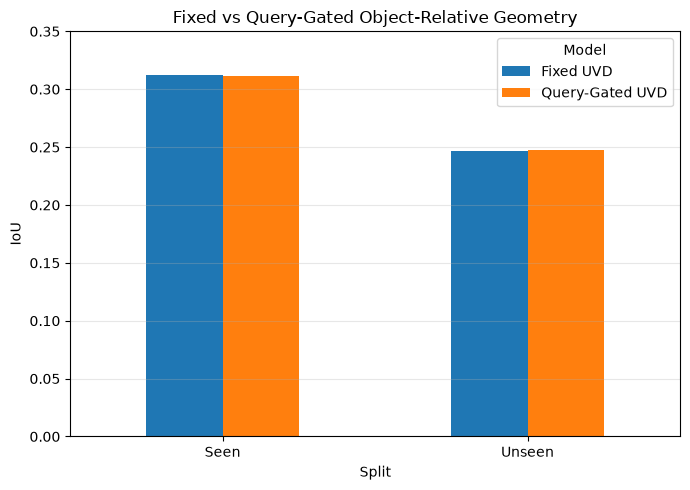

In [119]:
plot_df = pd.DataFrame({
    "Split": ["Seen", "Unseen"],
    "Fixed UVD": [
        fixed_seen["iou"],
        fixed_unseen["iou"],
    ],
    "Query-Gated UVD": [
        gated_seen["iou"],
        gated_unseen["iou"],
    ],
})

ax = plot_df.set_index("Split").plot(
    kind="bar",
    figsize=(7, 5),
)

ax.set_ylabel("IoU")
ax.set_title("Fixed vs Query-Gated Object-Relative Geometry")
ax.set_ylim(0, 0.35)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Model")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [120]:
figure_path = (
    OUTPUT_ROOT
    / "fixed_vs_query_gated_iou.png"
)

fig = ax.get_figure()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("Saved:", figure_path)


Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd/fixed_vs_query_gated_iou.png


## Per-query unseen IoU changes

Positive values mean query gating improves IoU relative to fixed UVD; negative values mean a regression. Very small-sample queries should be interpreted cautiously.


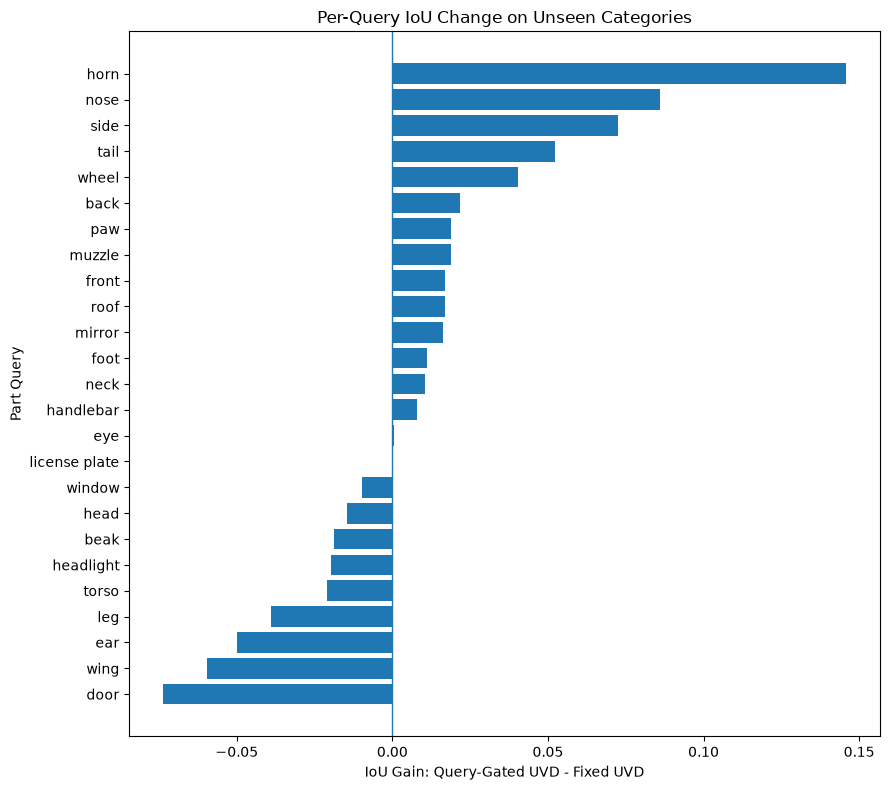

In [121]:
plot_df = unseen_query_results.sort_values(
    "gain",
    ascending=True,
)

plt.figure(figsize=(9, 8))

plt.barh(
    plot_df["query"],
    plot_df["gain"],
)

plt.axvline(
    0,
    linewidth=1,
)

plt.xlabel(
    "IoU Gain: Query-Gated UVD - Fixed UVD"
)

plt.ylabel("Part Query")

plt.title(
    "Per-Query IoU Change on Unseen Categories"
)

plt.tight_layout()
plt.show()


In [122]:
per_query_figure_path = (
    OUTPUT_ROOT
    / "unseen_per_query_iou_gain.png"
)

plt.gcf().savefig(
    per_query_figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("Saved:", per_query_figure_path)


Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd/unseen_per_query_iou_gain.png


<Figure size 640x480 with 0 Axes>

In [123]:
per_query_summary = {
    "num_unseen_queries": len(unseen_query_results),
    "gated_better_queries": int(
        (unseen_query_results["gain"] > 0).sum()
    ),
    "fixed_better_queries": int(
        (unseen_query_results["gain"] < 0).sum()
    ),
    "mean_per_query_iou_gain": float(
        unseen_query_results["gain"].mean()
    ),
    "median_per_query_iou_gain": float(
        unseen_query_results["gain"].median()
    ),
}

per_query_summary


{'num_unseen_queries': 25,
 'gated_better_queries': 16,
 'fixed_better_queries': 9,
 'mean_per_query_iou_gain': 0.009211337726443093,
 'median_per_query_iou_gain': 0.0104635194834196}

In [124]:
unseen_gate_weights = pd.read_csv(
    OUTPUT_ROOT
    / "unseen_gate_weights.csv"
)

print(
    unseen_gate_weights[
        ["alpha_u", "alpha_v", "alpha_d"]
    ].mean()
)

print("\nDominant geometry:")
print(
    unseen_gate_weights["dominant"]
    .value_counts()
)


alpha_u    3.997821e-01
alpha_v    6.002178e-01
alpha_d    8.124009e-08
dtype: float64

Dominant geometry:
dominant
alpha_v    15
alpha_u    10
Name: count, dtype: int64


## Learned geometry-weight visualization

A stacked bar plot shows the complete U/V/D distribution for each unseen query.


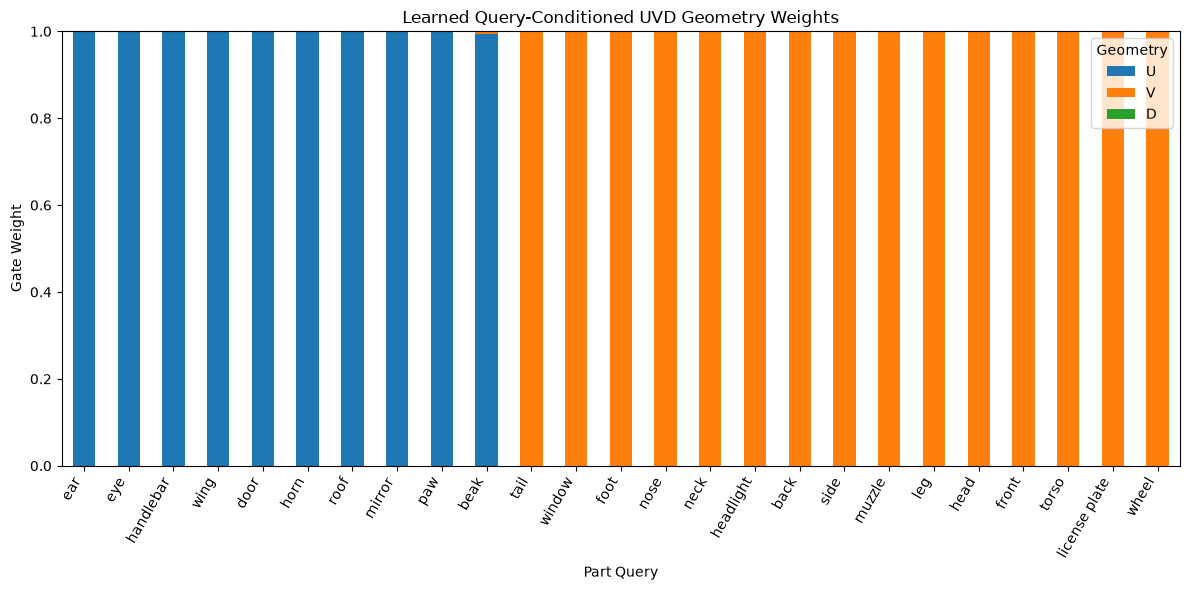

In [125]:
gate_plot_df = (
    unseen_gate_weights
    .sort_values("alpha_v")
    .set_index("query")
    [["alpha_u", "alpha_v", "alpha_d"]]
)

ax = gate_plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
)

ax.set_ylabel("Gate Weight")
ax.set_xlabel("Part Query")
ax.set_title(
    "Learned Query-Conditioned UVD Geometry Weights"
)

ax.set_ylim(0, 1)
ax.legend(
    ["U", "V", "D"],
    title="Geometry",
)

plt.xticks(
    rotation=60,
    ha="right",
)

plt.tight_layout()
plt.show()


In [126]:
gate_figure_path = (
    OUTPUT_ROOT
    / "unseen_query_gate_weights.png"
)

ax.get_figure().savefig(
    gate_figure_path,
    dpi=300,
    bbox_inches="tight",
)

print("Saved:", gate_figure_path)


Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd/unseen_query_gate_weights.png


## Seen-to-unseen generalization gap

Measure the absolute and relative IoU drop from seen to unseen parent-object categories.


In [127]:
generalization_df = pd.DataFrame([
    {
        "Model": "Fixed UVD",
        "Seen IoU": comparison_df.loc[
            comparison_df["Model"] == "Fixed UVD",
            "Seen IoU",
        ].iloc[0],
        "Unseen IoU": comparison_df.loc[
            comparison_df["Model"] == "Fixed UVD",
            "Unseen IoU",
        ].iloc[0],
    },
    {
        "Model": "Query-Gated UVD",
        "Seen IoU": comparison_df.loc[
            comparison_df["Model"] == "Query-Gated UVD",
            "Seen IoU",
        ].iloc[0],
        "Unseen IoU": comparison_df.loc[
            comparison_df["Model"] == "Query-Gated UVD",
            "Unseen IoU",
        ].iloc[0],
    },
])

generalization_df["Absolute Drop"] = (
    generalization_df["Seen IoU"]
    - generalization_df["Unseen IoU"]
)

generalization_df["Relative Drop (%)"] = (
    generalization_df["Absolute Drop"]
    / generalization_df["Seen IoU"]
    * 100
)

generalization_df.round(4)


,Model,Seen IoU,Unseen IoU,Absolute Drop,Relative Drop (%)
0,Fixed UVD,0.3122,0.2465,0.0657,21.0306
1,Query-Gated UVD,0.3117,0.2474,0.0643,20.6377


## Save derived findings

Build this summary from the computed DataFrames instead of hard-coding experiment numbers, so it stays correct if the notebook is rerun.


In [128]:
notebook09_findings = {
    "aggregate_results": {
        "fixed_seen_iou": float(fixed_seen["iou"]),
        "gated_seen_iou": float(gated_seen["iou"]),
        "fixed_unseen_iou": float(fixed_unseen["iou"]),
        "gated_unseen_iou": float(gated_unseen["iou"]),
        "unseen_iou_gain": float(gated_unseen["iou"] - fixed_unseen["iou"]),
    },
    "per_query_results": {
        "queries": int(len(unseen_query_results)),
        "gated_better": int((unseen_query_results["gain"] > 0).sum()),
        "fixed_better": int((unseen_query_results["gain"] < 0).sum()),
        "mean_iou_gain": float(unseen_query_results["gain"].mean()),
        "median_iou_gain": float(unseen_query_results["gain"].median()),
    },
    "generalization": {
        "fixed_relative_drop_percent": float(
            generalization_df.loc[
                generalization_df["Model"] == "Fixed UVD",
                "Relative Drop (%)",
            ].iloc[0]
        ),
        "gated_relative_drop_percent": float(
            generalization_df.loc[
                generalization_df["Model"] == "Query-Gated UVD",
                "Relative Drop (%)",
            ].iloc[0]
        ),
    },
    "gate_behavior": {
        "u_dominant_queries": int((unseen_gate_weights["dominant"] == "alpha_u").sum()),
        "v_dominant_queries": int((unseen_gate_weights["dominant"] == "alpha_v").sum()),
        "mean_alpha_d": float(unseen_gate_weights["alpha_d"].mean()),
        "observation": (
            "Gate saturates to near-binary U/V selection; "
            "boundary-distance D is effectively unused."
        ),
    },
}

findings_path = OUTPUT_ROOT / "notebook09_findings.json"
with open(findings_path, "w") as f:
    json.dump(notebook09_findings, f, indent=2)

print("Saved:", findings_path)


Saved: /home/hpc/v123be/v123be51/cv_notebooks/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd/notebook09_findings.json


## Conclusion

The conclusion is intentionally conservative: the aggregate gain is small, while the per-query analysis shows heterogeneous effects and the gate largely ignores D.


In [129]:
conclusion = """
Query-gated object-relative geometry achieved comparable performance
to fixed UVD geometry on seen categories (0.3117 vs. 0.3122 IoU) and
a small improvement on unseen categories (0.2474 vs. 0.2465 IoU).

At the part-query level, query gating improved 16 of 25 unseen queries,
with a mean IoU gain of 0.0092 and a median gain of 0.0105. This shows
that the aggregate improvement hides substantial query-specific effects.

The learned geometry gate strongly saturated toward near-binary U/V
selection. Of the 25 unseen queries, 15 were V-dominant and 10 were
U-dominant, while the boundary-distance D weight was effectively zero.
Therefore, the current model provides evidence that query-dependent
object-relative geometry can influence unseen-part generalization, but
does not demonstrate a strong overall advantage over fixed UVD geometry.
The collapse of the D channel is an important limitation and motivates
future investigation of gate regularization or alternative geometry
fusion mechanisms.
""".strip()

conclusion_path = (
    OUTPUT_ROOT
    / "notebook09_conclusion.txt"
)

conclusion_path.write_text(conclusion)

print(conclusion)
print("\nSaved:", conclusion_path)


Query-gated object-relative geometry achieved comparable performance
to fixed UVD geometry on seen categories (0.3117 vs. 0.3122 IoU) and
a small improvement on unseen categories (0.2474 vs. 0.2465 IoU).

At the part-query level, query gating improved 16 of 25 unseen queries,
with a mean IoU gain of 0.0092 and a median gain of 0.0105. This shows
that the aggregate improvement hides substantial query-specific effects.

The learned geometry gate strongly saturated toward near-binary U/V
selection. Of the 25 unseen queries, 15 were V-dominant and 10 were
U-dominant, while the boundary-distance D weight was effectively zero.
Therefore, the current model provides evidence that query-dependent
object-relative geometry can influence unseen-part generalization, but
does not demonstrate a strong overall advantage over fixed UVD geometry.
The collapse of the D channel is an important limitation and motivates
future investigation of gate regularization or alternative geometry
fusion mechanisms.

